# 07B — Random Forest Hyperparameter Tuning for Road Accident Severity Prediction

This notebook tunes the Random Forest developed in 07A. The goal is to investigate whether controlling tree complexity and ensemble settings can improve generalization.

**Important:** the test set is kept untouched during tuning. Hyperparameters are selected using cross-validation on the training data, with **macro F1** as the primary tuning metric because the severity classes are highly imbalanced.


## 1. Experimental objective

The 07A Random Forest showed a large train/test gap. In 07B we therefore tune parameters that control model complexity:

- `n_estimators`
- `max_depth`
- `min_samples_split`
- `min_samples_leaf`
- `max_features`

The tuned model will be compared with the 07A Random Forest using the untouched test set.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import sparse
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)
import joblib

RANDOM_STATE = 42
DATA_DIR = Path("../data")
OUTPUT_DIR = Path("../outputs")
MODEL_DIR = Path("../models")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)


## 2. Load the same selected features used in 07A

We reuse the preprocessing and Information Gain outputs. No preprocessing or feature selection is refitted here.


In [2]:
X_train_final = sparse.load_npz(DATA_DIR / "X_train_final.npz").tocsr()
X_test_final = sparse.load_npz(DATA_DIR / "X_test_final.npz").tocsr()
y_train = np.load(DATA_DIR / "y_train_encoded.npy")
y_test = np.load(DATA_DIR / "y_test_encoded.npy")
feature_names = pd.read_csv(DATA_DIR / "final_feature_names.csv").iloc[:, 0].astype(str).tolist()
selected_features_df = pd.read_csv(DATA_DIR / "selected_features_ig.csv")

selected_original = selected_features_df["original_feature"].astype(str).tolist()

print("Training matrix:", X_train_final.shape)
print("Testing matrix :", X_test_final.shape)
print("Selected original features:", len(selected_original))


Training matrix: (160278, 361)
Testing matrix : (40070, 361)
Selected original features: 26


In [3]:
categorical_original = {
    "ACCIDENT_TYPE", "DAY_OF_WEEK", "DCA_CODE_DESCRIPTION", "LIGHT_CONDITION",
    "POLICE_ATTEND", "ROAD_GEOMETRY", "SPEED_ZONE", "RUN_OFFROAD", "ROAD_NAME",
    "ROAD_TYPE", "LGA_NAME", "DTP_REGION", "DEG_URBAN_NAME", "SRNS", "RMA",
    "DIVIDED", "STAT_DIV_NAME"
}

selected_encoded = []
for original_feature in selected_original:
    if original_feature == "ROAD_NAME":
        matches = [i for i, n in enumerate(feature_names) if n == "ROAD_NAME_FREQ"]
    elif original_feature in categorical_original:
        matches = [
            i for i, n in enumerate(feature_names)
            if n.startswith(original_feature + "_")
        ]
    else:
        matches = [i for i, n in enumerate(feature_names) if n == original_feature]
    selected_encoded.extend(matches)

selected_encoded = sorted(set(selected_encoded))
X_train_selected = X_train_final[:, selected_encoded].tocsr()
X_test_selected = X_test_final[:, selected_encoded].tocsr()

print("Selected original features:", len(selected_original))
print("Selected encoded features:", len(selected_encoded))
print("Training matrix:", X_train_selected.shape)
print("Testing matrix :", X_test_selected.shape)

assert len(selected_encoded) == 136, "Expected 136 encoded features."


Selected original features: 26
Selected encoded features: 136
Training matrix: (160278, 136)
Testing matrix : (40070, 136)


## 3. 07A Random Forest reference model

These are the settings used for the main Random Forest in 07A. They provide the reference point for tuning.


In [4]:
rf_07a = RandomForestClassifier(
    n_estimators=100,
    max_features="sqrt",
    bootstrap=True,
    oob_score=True,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_07a.fit(X_train_selected, y_train)
y_pred_07a = rf_07a.predict(X_test_selected)
y_proba_07a = rf_07a.predict_proba(X_test_selected)

reference_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_07a),
    "Macro Precision": precision_score(y_test, y_pred_07a, average="macro", zero_division=0),
    "Macro Recall": recall_score(y_test, y_pred_07a, average="macro", zero_division=0),
    "Macro F1": f1_score(y_test, y_pred_07a, average="macro", zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, y_proba_07a, multi_class="ovr", average="macro")
}

print(pd.Series(reference_metrics).round(4))
print("OOB score:", round(rf_07a.oob_score_, 4))


Accuracy           0.6519
Macro Precision    0.4582
Macro Recall       0.4119
Macro F1           0.4145
ROC-AUC            0.7285
dtype: float64
OOB score: 0.6446


## 4. Hyperparameter search space

The search emphasizes parameters that can reduce overfitting while retaining enough trees for stable ensemble predictions.


In [5]:
param_distributions = {
    "n_estimators": [100, 150, 200, 300],
    "max_depth": [10, 15, 20, 25, 30, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10],
    "max_features": ["sqrt", "log2", 0.5]
}

for key, values in param_distributions.items():
    print(f"{key}: {values}")


n_estimators: [100, 150, 200, 300]
max_depth: [10, 15, 20, 25, 30, None]
min_samples_split: [2, 5, 10, 20]
min_samples_leaf: [1, 2, 5, 10]
max_features: ['sqrt', 'log2', 0.5]


## 5. Randomized cross-validation search

A randomized search is used instead of testing every possible combination. The test set is not used during this stage.

**Primary scoring metric:** macro F1.

Three-fold stratified cross-validation preserves class proportions in each fold.


In [6]:
cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=RANDOM_STATE
)

rf_search = RandomForestClassifier(
    bootstrap=True,
    oob_score=True,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

random_search = RandomizedSearchCV(
    estimator=rf_search,
    param_distributions=param_distributions,
    n_iter=10,
    scoring="f1_macro",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=1,
    verbose=2,
    return_train_score=True
)

random_search.fit(X_train_selected, y_train)

print("Best CV macro F1:", round(random_search.best_score_, 4))
print("Best parameters:")
print(random_search.best_params_)


Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV] END max_depth=None, max_features=0.5, min_samples_leaf=5, min_samples_split=5, n_estimators=200; total time= 5.3min
[CV] END max_depth=None, max_features=0.5, min_samples_leaf=5, min_samples_split=5, n_estimators=200; total time= 6.6min
[CV] END max_depth=None, max_features=0.5, min_samples_leaf=5, min_samples_split=5, n_estimators=200; total time= 5.3min
[CV] END max_depth=30, max_features=log2, min_samples_leaf=2, min_samples_split=20, n_estimators=100; total time=  24.6s
[CV] END max_depth=30, max_features=log2, min_samples_leaf=2, min_samples_split=20, n_estimators=100; total time=  21.7s
[CV] END max_depth=30, max_features=log2, min_samples_leaf=2, min_samples_split=20, n_estimators=100; total time=  25.8s
[CV] END max_depth=None, max_features=0.5, min_samples_leaf=5, min_samples_split=10, n_estimators=200; total time= 4.8min
[CV] END max_depth=None, max_features=0.5, min_samples_leaf=5, min_samples_split=10, n_esti

## 6. Inspect tuning results


In [7]:
cv_results = pd.DataFrame(random_search.cv_results_)
result_columns = [
    "rank_test_score", "mean_test_score", "std_test_score",
    "mean_train_score", "std_train_score", "params"
]
tuning_results = cv_results[result_columns].sort_values("rank_test_score")
display(tuning_results.head(10).round(4))

tuning_results.to_csv(
    OUTPUT_DIR / "07B_rf_tuning_results.csv",
    index=False
)


,rank_test_score,mean_test_score,std_test_score,mean_train_score,std_train_score,params
3,1,0.4140,0.0009,0.9732,0.0003,"{'n_estimators': 300, 'min_samples_split': 5, ..."
7,2,0.4135,0.0016,0.5205,0.0036,"{'n_estimators': 200, 'min_samples_split': 10,..."
2,3,0.4123,0.0006,0.6156,0.0050,"{'n_estimators': 200, 'min_samples_split': 10,..."
0,3,0.4123,0.0006,0.6156,0.0050,"{'n_estimators': 200, 'min_samples_split': 5, ..."
9,5,0.4119,0.0004,0.6165,0.0038,"{'n_estimators': 300, 'min_samples_split': 2, ..."
1,6,0.4039,0.0006,0.4763,0.0006,"{'n_estimators': 100, 'min_samples_split': 20,..."
4,7,0.4035,0.0004,0.5408,0.0024,"{'n_estimators': 100, 'min_samples_split': 5, ..."
6,8,0.4003,0.0007,0.4672,0.0007,"{'n_estimators': 200, 'min_samples_split': 2, ..."
8,9,0.3718,0.0013,0.3834,0.0019,"{'n_estimators': 300, 'min_samples_split': 5, ..."
5,10,0.3688,0.0026,0.3769,0.0027,"{'n_estimators': 150, 'min_samples_split': 10,..."


## 7. Train/evaluate the selected tuned Random Forest

The best configuration was selected using training-set cross-validation. It is now evaluated on the untouched test set.


In [11]:
best_rf = random_search.best_estimator_

y_pred_tuned = best_rf.predict(X_test_selected)
y_proba_tuned = best_rf.predict_proba(X_test_selected)

tuned_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_tuned),
    "Macro Precision": precision_score(y_test, y_pred_tuned, average="macro", zero_division=0),
    "Macro Recall": recall_score(y_test, y_pred_tuned, average="macro", zero_division=0),
    "Macro F1": f1_score(y_test, y_pred_tuned, average="macro", zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, y_proba_tuned, multi_class="ovr", average="macro")
}

print("Tuned Random Forest test metrics")
print(pd.Series(tuned_metrics).round(4))
print("Tuned OOB score:", round(best_rf.oob_score_, 4))


Tuned Random Forest test metrics
Accuracy           0.6516
Macro Precision    0.4915
Macro Recall       0.4124
Macro F1           0.4146
ROC-AUC            0.7432
dtype: float64
Tuned OOB score: 0.6486


## 8. Classification report and confusion matrix


                         precision    recall  f1-score   support

         Fatal accident       0.24      0.01      0.03       670
  Other injury accident       0.70      0.80      0.75     24989
Serious injury accident       0.53      0.42      0.47     14411

               accuracy                           0.65     40070
              macro avg       0.49      0.41      0.41     40070
           weighted avg       0.63      0.65      0.64     40070



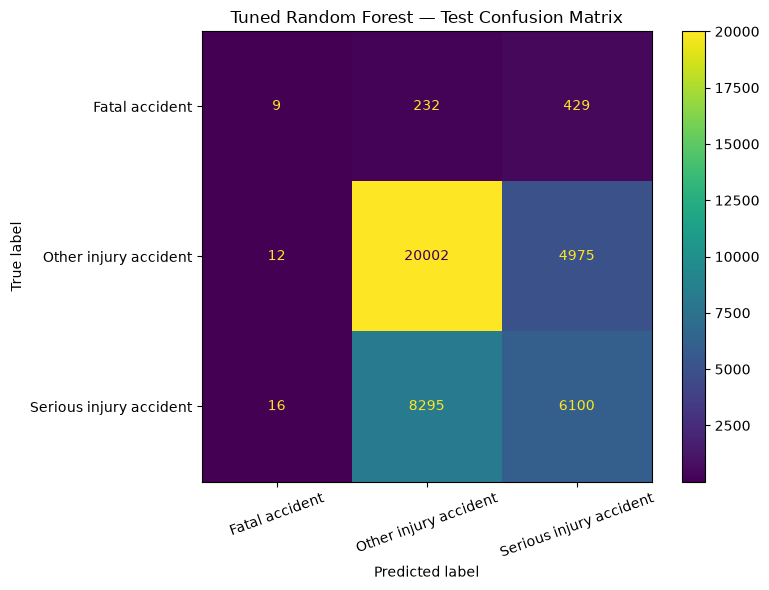

In [9]:
class_names = [
    "Fatal accident",
    "Other injury accident",
    "Serious injury accident"
]

print(classification_report(
    y_test,
    y_pred_tuned,
    target_names=class_names,
    zero_division=0
))

cm = confusion_matrix(y_test, y_pred_tuned)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, values_format="d", xticks_rotation=20)
ax.set_title("Tuned Random Forest — Test Confusion Matrix")
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "07B_tuned_rf_confusion_matrix.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()


## 9. Compare 07A and tuned Random Forest


In [10]:
comparison = pd.DataFrame(
    [reference_metrics, tuned_metrics],
    index=["07A Random Forest", "07B Tuned Random Forest"]
)
comparison["OOB Score"] = [
    rf_07a.oob_score_,
    best_rf.oob_score_
]

display(comparison.round(4))
comparison.to_csv(
    OUTPUT_DIR / "07B_rf_07A_vs_tuned_comparison.csv"
)


,Accuracy,Macro Precision,Macro Recall,Macro F1,ROC-AUC,OOB Score
07A Random Forest,0.6519,0.4582,0.4119,0.4145,0.7285,0.6446
07B Tuned Random Forest,0.6516,0.4915,0.4124,0.4146,0.7432,0.6486


## 10. Training vs test performance

A large gap between training and test macro F1 is evidence of poor generalization/overfitting. This comparison is descriptive and is not used to select the model.


In [12]:
train_pred_tuned = best_rf.predict(X_train_selected)
train_f1_tuned = f1_score(
    y_train, train_pred_tuned,
    average="macro",
    zero_division=0
)
test_f1_tuned = tuned_metrics["Macro F1"]

print(f"Tuned RF training macro F1: {train_f1_tuned:.4f}")
print(f"Tuned RF test macro F1    : {test_f1_tuned:.4f}")
print(f"Train-test macro F1 gap   : {train_f1_tuned - test_f1_tuned:.4f}")


Tuned RF training macro F1: 0.9699
Tuned RF test macro F1    : 0.4146
Train-test macro F1 gap   : 0.5553


## 11. Feature importance of the tuned model

Impurity-based feature importance is shown only as an exploratory interpretation of the tuned Random Forest. It should not be treated as causal evidence.


In [13]:
importance_df = pd.DataFrame({
    "feature": [feature_names[i] for i in selected_encoded],
    "importance": best_rf.feature_importances_
}).sort_values("importance", ascending=False)

display(importance_df.head(20).round(6))

importance_df.to_csv(
    OUTPUT_DIR / "07B_tuned_rf_feature_importance.csv",
    index=False
)


,feature,importance
2,LATITUDE,0.106336
5,VICGRID_Y,0.105766
4,VICGRID_X,0.104951
3,LONGITUDE,0.103985
19,ROAD_NAME_FREQ,0.082780
112,POLICE_ATTEND_Yes,0.051655
1,ROAD_ROUTE_1,0.047446
0,DCA_CODE,0.040626
7,MALES,0.028083
8,FEMALES,0.026618


## 12. Save the tuned model


In [14]:
model_path = MODEL_DIR / "random_forest_tuned_07B.joblib"
joblib.dump(best_rf, model_path)
print("Saved:", model_path)


Saved: ..\models\random_forest_tuned_07B.joblib


## 13. Conclusions

Complete the conclusions after execution using the actual results:

1. Which hyperparameters were selected by cross-validation?
2. Did the tuned model improve test macro F1 compared with 07A?
3. Did the training–test gap decrease?
4. What happened to Fatal-class recall?
5. Does Random Forest remain a useful candidate for the later model comparison?

Do not claim improvement unless the measured test results support it. A lack of improvement is also a valid experimental finding.


## Final check

The final model is evaluated on the test set only after cross-validation-based tuning. This preserves the test set as an unseen evaluation set and avoids using test performance to choose hyperparameters.
